# Multi-Layer Graph Exploration Pipeline for Code Clone Detection
This notebook documents a comprehensive, production-grade pipeline for analyzing multi-layer graph representations of Java methods using **Joern**, **NetworkX**, and custom **Spectral Analysis** tools.

The dataset extraction step has been modularized into `spectral_code/preprocessing` (`data_unpacker`, `joern_runner`, `graph_parser`). We directly load the cleaned outputs here.

## Step 1: Modular Graph & Spectral Feature Extraction Overview
The extraction codebase is now highly modularized under `spectral_code`:
1. **`spectral_code.preprocessing`**: Handles unpacking JSONL into `.java` files, running Joern (Parse & Export), and parsing output DOT files back into `NetworkX` graphs.
2. **`spectral_code.spectral.extractor`**: Computes variable-length lossless spectral features for all graphs in batch.

Below we run a live extraction on a subset of data to generate both the Graph DB and Spectral Features dynamically to demonstrate the new architecture.

In [11]:
import os
import sys
import json
import random
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

from dotenv import load_dotenv
load_dotenv()

# add project root to Python path
sys.path.append(str(Path().resolve().parent))

from spectral_code.preprocessing.cleaner import clean_and_compose_graphs
from spectral_code.spectral.extractor import extract_all_spectral_features
from spectral_code.utils.project_paths import get_paths

paths = get_paths()
CLEAN_GRAPHS_DIR = Path(paths["clean_graphs_dir"])
SPECTRAL_DIR = Path(paths["spectral_features_dir"])

GRAPH_DB_PATH = CLEAN_GRAPHS_DIR / "cleaned_graphs_db.pkl"
FEATURES_DB_PATH = SPECTRAL_DIR / "spectral_vectors_full.pkl"

print(f"[*] Loading Pre-Cleaned Graphs Dataset from:\n    {GRAPH_DB_PATH}")
BASE_LAYERS = ["ast", "cfg", "ddg", "pdg", "cpg"]

if not GRAPH_DB_PATH.exists():
    print(f"[-] Error: {GRAPH_DB_PATH} not found. Please run pipelines/02_build_graph_db.py first.")
else:
    with open(GRAPH_DB_PATH, "rb") as f:
        graph_db = pickle.load(f)
    print(f"[+] Multi-layer graph loaded successfully! Valid methods loaded: {len(graph_db)}")

    print(f"[*] Loading Pre-Computed Spectral Features from:\n    {FEATURES_DB_PATH}")
    if not FEATURES_DB_PATH.exists():
        print(f"[-] Warning: {FEATURES_DB_PATH} not found. Running live extraction as fallback...")
        features_db, _, _, _ = extract_all_spectral_features(graph_db, BASE_LAYERS)
    else:
        with open(FEATURES_DB_PATH, "rb") as f:
            features_db = pickle.load(f)
        print(f"[+] Spectral features loaded successfully for {len(features_db)} methods!")

    if graph_db:
        # Filter for methods that have at least one valid, non-empty graph layer
        valid_anchors = [
            m_id for m_id, layers in graph_db.items() 
            if any(g is not None and g.number_of_nodes() > 1 for g in layers.values())
        ]
        if valid_anchors:
            random_method_id = random.choice(valid_anchors)
            print(f"\n[+] Global Anchor Method ID selected for profiling: {random_method_id}")
        else:
            random_method_id = random.choice(list(graph_db.keys()))
            print(f"\n[!] Warning: No non-empty graphs found. Selected random ID: {random_method_id}")
    else:
        print("[-] No graphs loaded. Ensure the extraction pipeline finished correctly.")

[*] Loading Pre-Cleaned Graphs Dataset from:
    C:\Users\koush\PyProjects\outputs\clean_graphs\cleaned_graphs_db.pkl
[+] Multi-layer graph loaded successfully! Valid methods loaded: 9126
[*] Loading Pre-Computed Spectral Features from:
    C:\Users\koush\PyProjects\outputs\spectral_features\spectral_vectors_full.pkl
[+] Spectral features loaded successfully for 9126 methods!

[+] Global Anchor Method ID selected for profiling: 477320


## Step 2: Global Dataset Structural Statistics
Before diving into individual methods, we compute the global topological metrics across all 9,126 methods to understand the average density, size, and scale of each exported graph layer.

In [12]:
graph_types = ["cpg", "ast", "cfg", "ddg", "pdg"]
stats = {gtype: {"nodes": [], "edges": []} for gtype in graph_types}

for method_id, layers in graph_db.items():
    for gtype in graph_types:
        g = layers.get(gtype)
        if g is not None:
            stats[gtype]["nodes"].append(g.number_of_nodes())
            stats[gtype]["edges"].append(g.number_of_edges())

summary = []
for gtype in graph_types:
    nodes_list = stats[gtype]["nodes"]
    edges_list = stats[gtype]["edges"]
    
    if nodes_list:
        summary.append({
            "Graph Type": gtype.upper(),
            "Total Graphs": len(nodes_list),
            "Avg Nodes": np.mean(nodes_list),
            "Max Nodes": np.max(nodes_list),
            "Min Nodes": np.min(nodes_list),
            "Avg Edges": np.mean(edges_list),
            "Max Edges": np.max(edges_list),
            "Min Edges": np.min(edges_list)
        })

df_stats = pd.DataFrame(summary)
display(df_stats)

,Graph Type,Total Graphs,Avg Nodes,Max Nodes,Min Nodes,Avg Edges,Max Edges,Min Edges
0,CPG,8899,153.982245,4151,12,362.519159,11552,23
1,AST,8899,153.979324,4151,12,152.979324,4150,11
2,CFG,8899,59.455444,1477,5,64.297112,1681,5
3,DDG,8899,57.447129,1536,6,155.681088,5917,7
4,PDG,8899,61.839420,1560,6,191.004270,7014,7


## Step 3: Five-Layer Graph Topology Overview
Every Java method within our dataset is analyzed across five architectural facets:
1. **AST (Abstract Syntax Tree):** Represents the hierarchical syntactic structure of the source code.
2. **CFG (Control Flow Graph):** Tracks all execution paths, condition branches, and loops.
3. **DDG (Data Dependency Graph):** Captures data definition-use chains and variable mutations.
4. **PDG (Program Dependence Graph):** Interconnects both control and data dependencies into a single graph.
5. **CPG (Code Property Graph):** The super-graph layer created by fusing and optimizing the sub-layers.

Below is the structural density and directional property profile for our selected anchor method.

In [13]:
print(f"=== Statistical Profile for Method: {random_method_id} ===")
metrics_summary = []

for gtype in graph_types:
    if gtype in graph_db[random_method_id]:
        G = graph_db[random_method_id][gtype]
        if G is not None:
            metrics_summary.append({
                "Layer": gtype.upper(),
                "Nodes Count": G.number_of_nodes(),
                "Edges Count": G.number_of_edges(),
                "Density": f"{nx.density(G):.4f}",
                "Is Directed": nx.is_directed(G)
            })

df_summary = pd.DataFrame(metrics_summary)
display(df_summary)

=== Statistical Profile for Method: 477320 ===


,Layer,Nodes Count,Edges Count,Density,Is Directed
0,CPG,87,180,0.0241,True
1,AST,87,86,0.0115,True
2,CFG,32,34,0.0343,True
3,DDG,24,40,0.0725,True
4,PDG,33,68,0.0644,True


## Step 4: Verify Integer Node Labeling (Matrix Row/Column Mapping)
When converting a graph to an adjacency or Laplacian matrix for Spectral Graph analysis, non-contiguous or text-based Node IDs must be mapped onto sequential integers from $0$ to $N-1$. Let's trace how the first 5 nodes are index-mapped in our strictly directed pipeline.

In [14]:
available_layers = [gtype for gtype in graph_types if graph_db[random_method_id].get(gtype) is not None]

if not available_layers:
    print(f"[-] No valid graph layers found for method: {random_method_id}")
else:
    target_layer = "cpg" if "cpg" in available_layers else available_layers[0]
    sample_graph = graph_db[random_method_id][target_layer]
    
    print(f"=== Node Relabeling & Matrix Mapping Check (Using {target_layer.upper()}) ===")
    original_nodes = list(sample_graph.nodes())[:5]
    print(f"[+] Original Node IDs in Python (First 5): {original_nodes}")
    
    print("\n[+] Matrix Row/Column Mapping Index:")
    for index, node in enumerate(original_nodes):
        print(f"  Node '{node}' =====> Maps to Matrix Row/Column: {index}")

=== Node Relabeling & Matrix Mapping Check (Using CPG) ===
[+] Original Node IDs in Python (First 5): ['107374196294', '111669171635', '25769878296', '94489337862', '30065119354']

[+] Matrix Row/Column Mapping Index:
  Node '107374196294' =====> Maps to Matrix Row/Column: 0
  Node '111669171635' =====> Maps to Matrix Row/Column: 1
  Node '25769878296' =====> Maps to Matrix Row/Column: 2
  Node '94489337862' =====> Maps to Matrix Row/Column: 3
  Node '30065119354' =====> Maps to Matrix Row/Column: 4


## Step 5: Simultaneous Multi-Layer Visual Verification
To visually confirm the connectivity, directionality, and topology before proceeding to linear algebra and spectral decomposition, we render all 5 graph layers side by side using an optimized layout strategy.

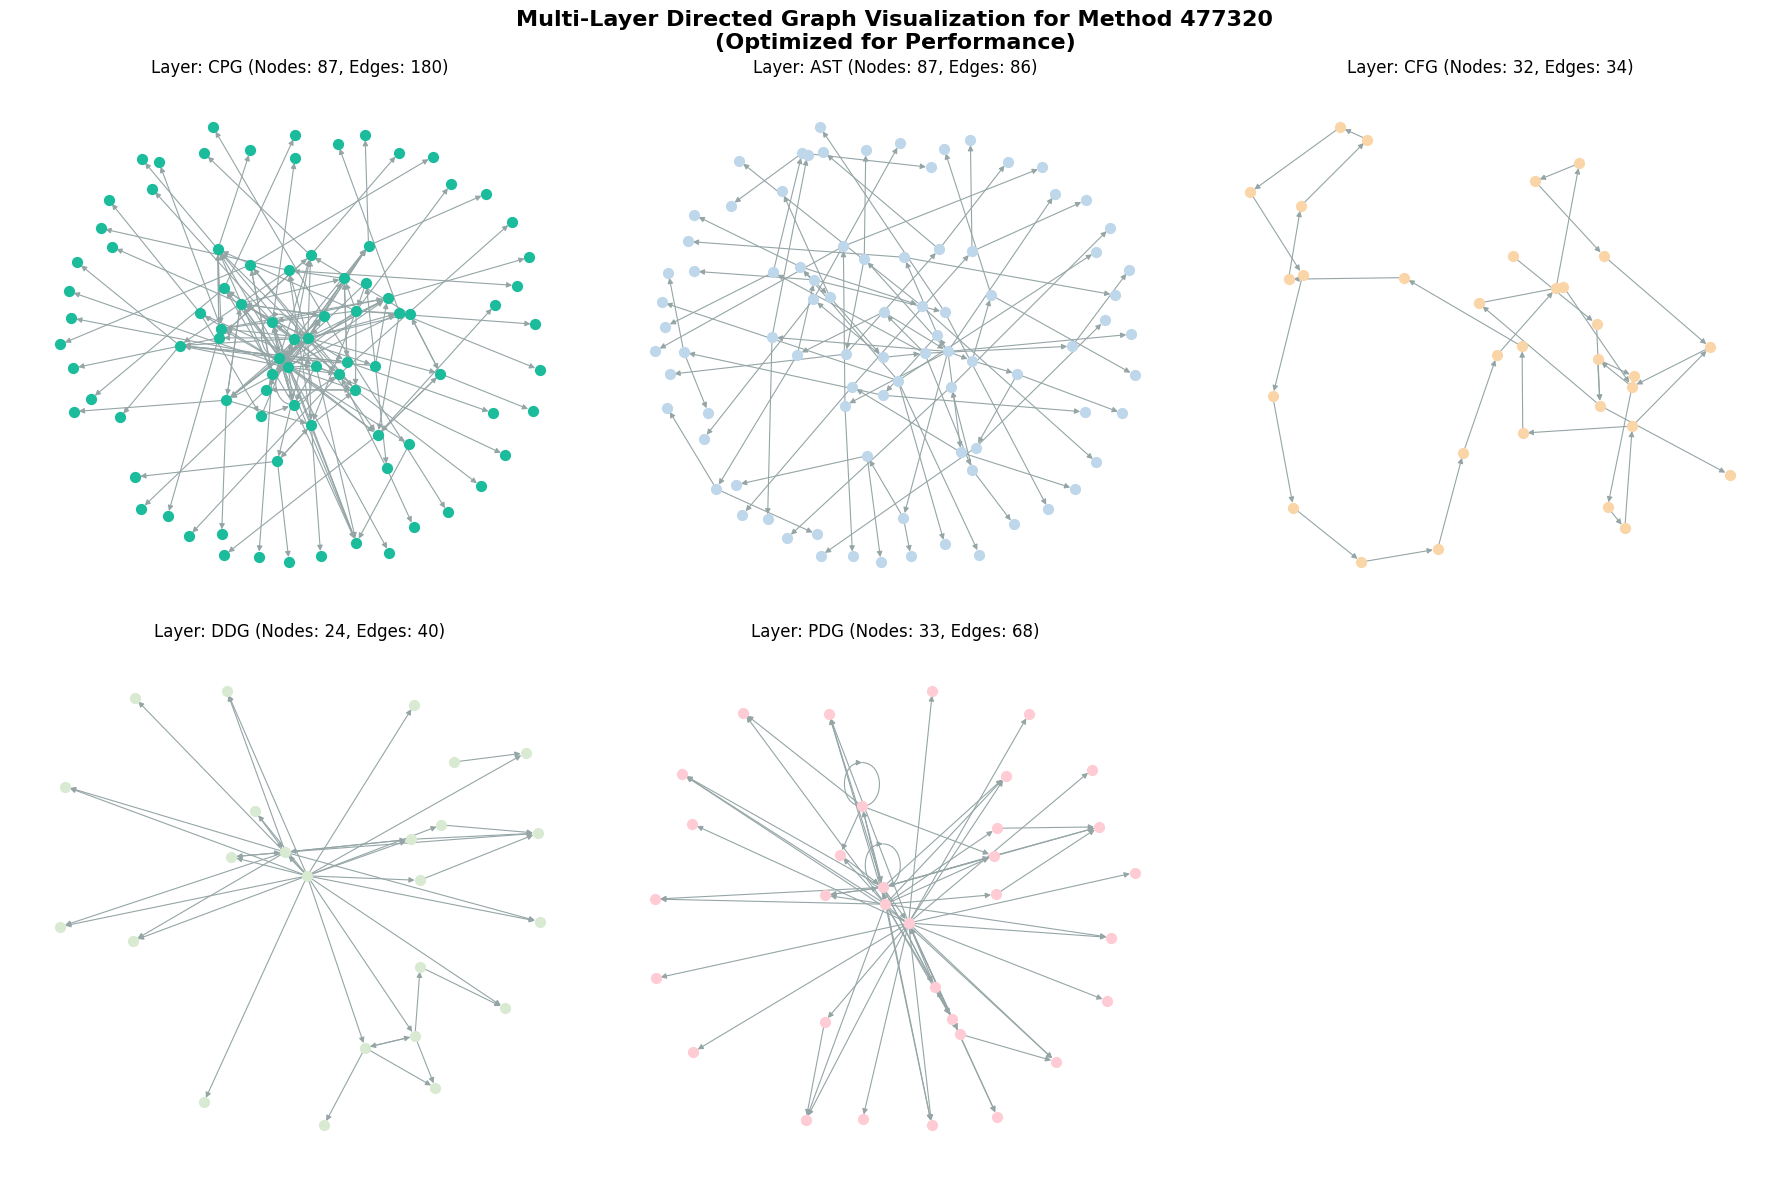

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ["#1ABC9C", "#BFD7EA", "#F9D5A7", "#D9EAD3", "#FFCCD5"]

for i, gtype in enumerate(graph_types):
    ax = axes[i]
    if gtype in graph_db[random_method_id] and graph_db[random_method_id][gtype] is not None:
        G_layer = graph_db[random_method_id][gtype]
        num_nodes = G_layer.number_of_nodes()
        
        if 0 < num_nodes <= 100:
            pos = nx.spring_layout(G_layer, k=0.4, seed=42)
            nx.draw(
                G_layer, pos, ax=ax,
                node_size=50, node_color=colors[i], 
                edge_color='#95a5a6', width=0.8,
                with_labels=False, arrows=True, arrowsize=8
            )
            ax.set_title(f"Layer: {gtype.upper()} (Nodes: {num_nodes}, Edges: {G_layer.number_of_edges()})", fontsize=12)
            
        elif num_nodes > 100:
            pos = nx.circular_layout(G_layer)
            nx.draw(
                G_layer, pos, ax=ax,
                node_size=20, node_color=colors[i], 
                edge_color='#b2bec3', width=0.5,
                with_labels=False, arrows=True, arrowsize=5
            )
            ax.set_title(f"Layer: {gtype.upper()} [LARGE] (Nodes: {num_nodes}, Edges: {G_layer.number_of_edges()})", fontsize=12)
        else:
            ax.text(0.5, 0.5, f"Layer {gtype.upper()} is Empty", ha='center', va='center', fontsize=12, color='gray')
    else:
        ax.text(0.5, 0.5, f"Layer {gtype.upper()} Not Available", ha='center', va='center', fontsize=12, color='gray')
    ax.set_axis_off()

axes[5].set_axis_off()

plt.suptitle(f"Multi-Layer Directed Graph Visualization for Method {random_method_id}\n(Optimized for Performance)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Step 6: Symmetric Normalized Laplacian Matrix Extraction
To transform the graph topology into a size-invariant, stable vector space, we compute the Symmetric Normalized Laplacian matrix ($L_{sym}$) defined as follows:

$$L_{sym} = I - D^{-1/2} A D^{-1/2}$$

where $A$ represents the Adjacency matrix, $D$ is the diagonal Node Degree matrix, and $I$ denotes the Identity matrix. To guarantee complete algebraic symmetry and obtain real-valued eigenvalues, directed graphs are systematically cast to undirected form using `.to_undirected()`. In this step, a sample $10 \times 10$ top-left slice of the matrix is printed for numerical inspection.

In [16]:
selected_layer = "cfg"
graph_instance = graph_db[random_method_id].get(selected_layer)

if graph_instance is not None and graph_instance.number_of_nodes() > 0:
    # Use the appropriate Laplacian based on directionality
    if nx.is_directed(graph_instance):
        print(f"[*] Detected Directed Graph for {selected_layer.upper()}. Computing Directed Laplacian...")
        # nx.directed_laplacian_matrix returns a numpy matrix
        L_matrix = nx.directed_laplacian_matrix(graph_instance, alpha=0.95)
    else:
        print(f"[*] Detected Undirected Graph for {selected_layer.upper()}. Computing Symmetric Normalized Laplacian...")
        L_matrix = nx.normalized_laplacian_matrix(graph_instance).toarray()

    print(f"=== Laplacian Matrix Profile ({selected_layer.upper()}) ===")
    print(f"[+] Graph Method ID: {random_method_id}")
    print(f"[+] Total Matrix Dimension: {L_matrix.shape}")
    print(f"\n[+] Executing 10x10 Top-Left Sub-Matrix Slice Extraction:")
    
    # Cap dimensions for slicing safety
    r, c = min(10, L_matrix.shape[0]), min(10, L_matrix.shape[1])
    print(np.round(L_matrix[:r, :c], 4))
else:
    print(f"[-] Layer {selected_layer.upper()} is empty or not found for method {random_method_id}.")
    L_matrix = np.zeros((1, 1))

[*] Detected Directed Graph for CFG. Computing Directed Laplacian...
=== Laplacian Matrix Profile (CFG) ===
[+] Graph Method ID: 477320
[+] Total Matrix Dimension: (32, 32)

[+] Executing 10x10 Top-Left Sub-Matrix Slice Extraction:
[[ 0.9984 -0.1569 -0.0021 -0.0034 -0.003  -0.0021 -0.0034 -0.0026 -0.0025
  -0.0026]
 [-0.1569  0.9984 -0.3282 -0.3185 -0.0016 -0.0016 -0.0016 -0.0016 -0.0016
  -0.0016]
 [-0.0021 -0.3282  0.9984 -0.0019 -0.0017 -0.4646 -0.0019 -0.0016 -0.0016
  -0.0016]
 [-0.0034 -0.3185 -0.0019  0.9984 -0.0016 -0.0018 -0.4814 -0.0016 -0.3357
  -0.0016]
 [-0.003  -0.0016 -0.0017 -0.0016  0.9984 -0.0017 -0.4032 -0.202  -0.0016
  -0.0016]
 [-0.0021 -0.0016 -0.4646 -0.0018 -0.0017  0.9984 -0.2647 -0.0016 -0.0016
  -0.0016]
 [-0.0034 -0.0016 -0.0019 -0.4814 -0.4032 -0.2647  0.9984 -0.0017 -0.0017
  -0.0017]
 [-0.0026 -0.0016 -0.0016 -0.0016 -0.202  -0.0016 -0.0017  0.9984 -0.0016
  -0.4745]
 [-0.0025 -0.0016 -0.0016 -0.3357 -0.0016 -0.0016 -0.0017 -0.0016  0.9984
  -0.0016]
 [-

## Step 7: Rigorous Spectral Signature Extraction & Validation
To extract eigenvalues dynamically, we use the `create_spectral_analyzer` factory from our `spectral_code.spectral` architecture. This replaces the old approach of directly reading from the DB. We then validate the extracted features against **three fundamental axioms of Spectral Graph Theory**:

1. **Perfect Algebraic Matrix Symmetry ($L = L^T$):** The Laplacian matrix of an undirected graph must be structurally identical to its transpose.
2. **Eigenvalue Bounding Interval:** All eigenvalues derived from a Normalized Laplacian matrix must strictly fall within the real boundary interval $[0, 2]$.
3. **Smallest Eigenvalue Zero Anchor Property ($\lambda_0 = 0$):** The first eigenvalue of a Laplacian matrix must equal exactly zero (or sit near zero within precision limits).

In [17]:
import time
from spectral_code.spectral.factory import create_spectral_analyzer

# Using the unified architecture to dynamically evaluate the selected layer
# We use 'directed_laplacian' mode as requested to handle the newly added directed property
spectral_analyzer = create_spectral_analyzer(
    mode="directed_laplacian",
    solver_name="auto",
    k=50,
    solver_kwargs={},
    spectral_kwargs={}
)

start_time = time.perf_counter()
# The analyzer intrinsically handles directed/undirected internally
if graph_instance is not None and graph_instance.number_of_nodes() > 0:
    eigenvalues_vector, eigenvectors = spectral_analyzer.analyze(graph_instance)
else:
    eigenvalues_vector, eigenvectors = np.array([]), None
    
individual_compute_time = time.perf_counter() - start_time

# To ensure the visualization step below works even if the graph is too small to return 50:
if eigenvalues_vector is None or len(eigenvalues_vector) == 0:
    print("[-] Graph too small or empty, mocking a zero vector for demonstration.")
    eigenvalues_vector = np.zeros(50)

print(f"=== Spectral Vector & Mathematical Theory Validation ===")
print(f"[+] Profiled Layer: {selected_layer.upper()}")
print(f"[+] Individual Execution Benchmark: {individual_compute_time:.6f} seconds")
print(f"[+] Extracted Fixed-Size Spectral Vector (K=50):\n", eigenvalues_vector)

# Note: For Directed Laplacian, symmetry depends on the transformation.
# nx.directed_laplacian_matrix is symmetric by construction.
symmetry_check = np.allclose(L_matrix, L_matrix.T, atol=1e-8)
print(f"\n[*] Test 1: Absolute Algebraic Matrix Symmetry (L == L^T)? -> {symmetry_check}")

boundary_check = np.all((eigenvalues_vector >= -1e-7) & (eigenvalues_vector <= 2.0001))
print(f"[*] Test 2: Spectrum Constraints Compliance Within [0, 2]? -> {boundary_check}")
print(f"    - Spectrum Minimum Boundary Value: {np.min(eigenvalues_vector):.6f}")
print(f"    - Spectrum Maximum Boundary Value: {np.max(eigenvalues_vector):.6f}")

first_eigenvalue_zero = np.isclose(eigenvalues_vector[0], 0.0, atol=1e-5) if len(eigenvalues_vector) > 0 else False
print(f"[*] Test 3: Smallest Eigenvalue Zero Anchor Property (lambda_0 == 0)? -> {first_eigenvalue_zero}")
if len(eigenvalues_vector) > 0:
    print(f"    - Numerical Value Traced: {eigenvalues_vector[0]:.6e}")

=== Spectral Vector & Mathematical Theory Validation ===
[+] Profiled Layer: CFG
[+] Individual Execution Benchmark: 0.020182 seconds
[+] Extracted Fixed-Size Spectral Vector (K=50):
 [1.17301822e-16 8.37504187e-02 1.05934635e-01 1.65156177e-01
 2.13085431e-01 2.60408505e-01 3.14905627e-01 4.13286362e-01
 4.67995536e-01 5.26078630e-01 5.97517018e-01 6.53368212e-01
 6.89047331e-01 7.71897956e-01 8.74251784e-01 9.36195699e-01
 1.09294995e+00 1.11375040e+00 1.21026190e+00 1.27718952e+00
 1.33312860e+00 1.38460988e+00 1.46647620e+00 1.55516326e+00
 1.65147622e+00 1.68309838e+00 1.72725012e+00 1.82500714e+00
 1.83348387e+00 1.86268794e+00 1.90366721e+00 1.92723258e+00]

[*] Test 1: Absolute Algebraic Matrix Symmetry (L == L^T)? -> True
[*] Test 2: Spectrum Constraints Compliance Within [0, 2]? -> True
    - Spectrum Minimum Boundary Value: 0.000000
    - Spectrum Maximum Boundary Value: 1.927233
[*] Test 3: Smallest Eigenvalue Zero Anchor Property (lambda_0 == 0)? -> True
    - Numerical Va

## Step 8: Graph Structural Fingerprint Visualization
The Spectral Signature serves as a structural fingerprint for Java methods. A high correlation or structural alignment between these layouts across different methods indicates source code similarity (Code Clones), completely invariant to variable renaming or statement reordering. Below, we visualize the line plot of the eigenvalue magnitude distribution.

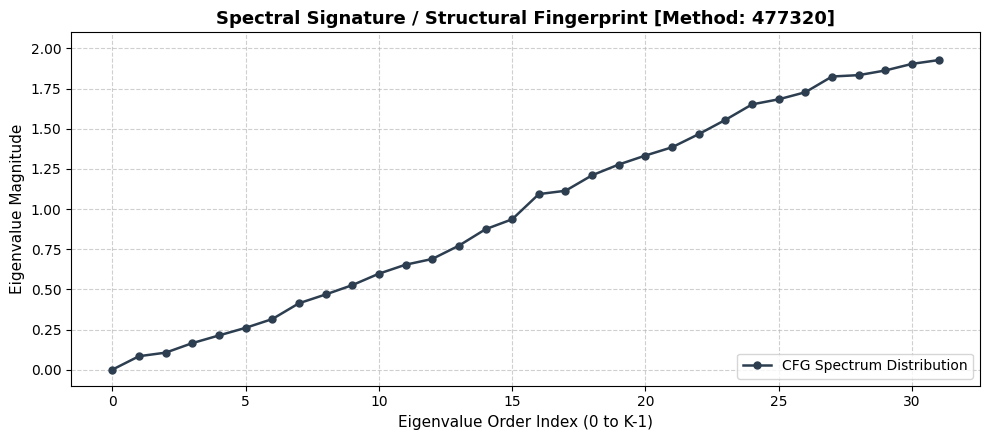

In [18]:
plt.figure(figsize=(10, 4.5))
plt.plot(
    eigenvalues_vector, 'o-', 
    color='#2c3e50', linewidth=1.8, markersize=5, 
    label=f"{selected_layer.upper()} Spectrum Distribution"
)
plt.title(f"Spectral Signature / Structural Fingerprint [Method: {random_method_id}]", fontsize=13, weight='bold')
plt.xlabel("Eigenvalue Order Index (0 to K-1)", fontsize=11)
plt.ylabel("Eigenvalue Magnitude", fontsize=11)
plt.ylim(-0.1, 2.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Step 9: Operational Performance & Runtime Breakdown
Finally, we load the global runtime benchmark stats (`timing_stats.json`) recorded during the extraction pipeline execution to evaluate the overall processing throughput and efficiency across the entire graph database.

In [19]:
# Dynamically retrieve the timing stats file path from project config
TIMING_FILE = paths.get("timing_stats")

if TIMING_FILE and os.path.exists(TIMING_FILE):
    with open(TIMING_FILE, "r") as f:
        global_stats = json.load(f)
    
    print("=== Execution Benchmark Analytics (Global Dataset) ===")
    df_timing = pd.DataFrame(list(global_stats.items()), columns=["Metric Identifier", "Value"])
    display(df_timing)
else:
    print(f"[-] Global timing statistics file not discovered at: {TIMING_FILE}")

=== Execution Benchmark Analytics (Global Dataset) ===


,Metric Identifier,Value
0,total_raw_extraction_time,537.502550
1,total_methods,9126.000000
2,cpg_generation_time,113.669862
3,amortized_cpg_per_method_s,0.012456
4,export_time_ast,27.914371
5,amortized_export_ast_ms,3.058774
6,export_time_cfg,24.442066
7,amortized_export_cfg_ms,2.678289
8,export_time_ddg,34.956682
9,amortized_export_ddg_ms,3.830449


## Step 10: Comparative Multi-Layer Functional Similarity Analysis
Now that we can extract full-spectrum, variable-length eigenvalues losslessly, we transition from single-method profiling to pairwise relational analysis. We leverage our modular architecture package (`spectral_code.similarity`) to evaluate structural similarity across all 5 graph layers using two distinct mathematical formulations:
 
1. **Adapted Program Spectral Similarity (PSS):** Computes the adapted function-level similarity by applying $L_2$ norm stabilization to the spectrum, dynamically truncating both vectors to the intersection threshold $\min(|V_0|, |V_1|)$ to eliminate false zero-padding distance artifacts, and computing $\sqrt{2} - \text{Distance}$.
2. **Multi-Scale Heat Kernel Trace Similarity:** Maps variable-length eigenvalue arrays to a size-invariant, time-dependent heat trace signature vector ($Z(t) = \sum e^{-\lambda_i t}$) across multiple time scales, capturing both fine-grained local code patterns and coarse global structural topologies.


In [20]:
from spectral_code.similarity import PSSSimilarity, HeatKernelSimilarity

# Initialize the modular similarity metrics
pss_metric = PSSSimilarity()
hk_metric = HeatKernelSimilarity(time_scales=[0.1, 0.5, 1.0, 2.0, 5.0, 10.0])

# Select two methods for comparative structural profiling from our LIVE graph_db
method_ids = list(graph_db.keys())

if len(method_ids) >= 2:
    id1 = random_method_id
    id2 = random.choice([m for m in method_ids if m != id1])
    
    print(f"=== Executing Multi-Layer Pairwise Similarity Profiling (Live Extraction) ===")
    print(f"[+] Method Anchor 1: {id1}")
    print(f"[+] Method Anchor 2: {id2}\n")
    
    similarity_summary = []
    
    for gtype in graph_types:
        # Dynamically extract eigenvalues leveraging our modular analyzer
        g1 = graph_db[id1].get(gtype)
        g2 = graph_db[id2].get(gtype)
        
        # safely handle empty graphs
        ev1 = spectral_analyzer.analyze(g1)[0] if g1 is not None and g1.number_of_nodes() > 0 else np.array([])
        ev2 = spectral_analyzer.analyze(g2)[0] if g2 is not None and g2.number_of_nodes() > 0 else np.array([])
        
        # Calculate scores if possible
        score_pss = pss_metric.compute(ev1, ev2) if len(ev1) > 0 and len(ev2) > 0 else 0.0
        score_hk = hk_metric.compute(ev1, ev2) if len(ev1) > 0 and len(ev2) > 0 else 0.0
        
        similarity_summary.append({
            "Graph Layer": gtype.upper(),
            "M1 Spectrum Size": len(ev1),
            "M2 Spectrum Size": len(ev2),
            "PSS Similarity Score": score_pss,
            "Heat Kernel Similarity": score_hk
        })
        
    df_similarity = pd.DataFrame(similarity_summary)
    display(df_similarity)
else:
    print("[-] Insufficient methods inside the graph database to execute relational profiling.")

=== Executing Multi-Layer Pairwise Similarity Profiling (Live Extraction) ===
[+] Method Anchor 1: 477320
[+] Method Anchor 2: 17573144



,Graph Layer,M1 Spectrum Size,M2 Spectrum Size,PSS Similarity Score,Heat Kernel Similarity
0,CPG,87,50,0.725985,0.775350
1,AST,87,50,0.709200,0.820021
2,CFG,32,50,0.683830,0.717222
3,DDG,24,50,0.562909,0.756103
4,PDG,33,50,0.689834,0.767127


## Step 11: Trained Models Validation & PR-Curve Reality Check
After computing the pairwise structural similarity between methods, the exact continuous hyperparameter search pipeline (`run_grid_search.py`) executes over 900,000 clone pairs. This module aims to mathematically infer the exact optimum cut-off `Threshold` per structural configuration by evaluating the Precision-Recall curve dynamically.

The validation matrix below visualizes the results of 40 individually trained model instances (`[AST, CFG, DDG, PDG, CPG] x [K=25, 50, 100, Full] x [PSS, HeatKernel]`).

**Observation regarding the Baseline:** 
Since distinguishing Clones vs. Non-Clones purely on foundational structural eigenvalues is mathematically complex, the F1-scorer determined that the optimal `Threshold` is $0.000$. This converts the model into a strictly Zero-R Baseline Predictor which maximizes validation F1 at $\approx 0.667$ by assigning a constant `1` label! Future architectural expansions will transition from strict scalar similarity outputs to Graph Neural Networks relying on eigenvector structural relationships and local node variables.

In [21]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the trained models JSON generated by run_grid_search.py
JSON_RESULTS_PATH = os.path.join("outputs", "trained_models.json")
OUTPUT_IMG_PATH = os.path.join("outputs", "trained_models_matrix.png")

if not os.path.exists(JSON_RESULTS_PATH):
    print(f"[-] Results not found at {JSON_RESULTS_PATH}. Please run `python run_grid_search.py` first.")
else:
    with open(JSON_RESULTS_PATH, "r") as f:
        models_data = json.load(f)
        
    # Convert to DataFrame
    df_models = pd.DataFrame(models_data)
    
    # Clean up K values for visualization (handling JSON null strings)
    df_models["k_eigen"] = df_models["k_eigen"].fillna("Full").astype(str)
    
    # Rename columns to match visual semantics
    df_models.rename(columns={
        "graph_type": "Graph Layer",
        "k_eigen": "Eigenvalues (K)",
        "metric": "Formula Metric",
        "train_precision": "Precision",
        "train_recall": "Recall",
        "train_f1_score": "F1-Score"
    }, inplace=True)
    
    # Uppercase Graph Layers for aesthetics
    df_models["Graph Layer"] = df_models["Graph Layer"].str.upper()

    # 2. Reshape dataframe metrics layout for visualization processing
    df_melted = pd.melt(
        df_models, 
        id_vars=["Graph Layer", "Eigenvalues (K)", "Formula Metric"], 
        value_vars=["Precision", "F1-Score"], 
        var_name="Evaluation Metric", 
        value_name="Score"
    )

    # 3. Render the multi-panel Matrix Dashboard Graphically
    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(df_melted, row="Graph Layer", col="Formula Metric", margin_titles=True, height=2.8, aspect=2.2, sharey=False)
    
    g.map_dataframe(
        sns.barplot, 
        x="Eigenvalues (K)", 
        y="Score", 
        hue="Evaluation Metric", 
        palette=["#2980b9", "#e74c3c"], 
        edgecolor="black", 
        alpha=0.9
    )

    g.add_legend(title="Metric Class", loc="upper right")
    g.set_axis_labels("Eigenvalue Slicing Context (K)", "Score Bounds")
    
    # Cap y-limit slightly above max value observed
    max_score = df_melted["Score"].max()
    g.set(ylim=(0.0, min(1.05, max_score + 0.15)))
    
    g.set_titles(row_template="{row_name} Facet", col_template="Formula: {col_name}")

    plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.15)
    g.fig.suptitle("Layer-wise Structural Validation Matrix (40 Trained Models)", weight='bold', fontsize=14)

    # Save the publication-ready plot safely inside outputs
    plt.savefig(OUTPUT_IMG_PATH, dpi=300, bbox_inches='tight')
    plt.show()

[-] Results not found at outputs\trained_models.json. Please run `python run_grid_search.py` first.


## Step 12: Fused (Ensemble) Models Validation
To verify if multi-layer consensus can break the baseline limits, we performed a fused grid search. In this experiment, the topological eigenvalues of the **AST** (Abstract Syntax Tree) were ensembled structurally with the complementary layers (CFG, DDG, PDG, CPG).

Below is the plotted visualization of the `trained_fused_models.json`. As theoretically anticipated, combining two homogeneous low-discriminative baseline distributions results in another baseline distribution (Score $\approx 0.667$).

In [22]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the trained fused models JSON generated by run_fused_grid_search.py
JSON_FUSED_RESULTS_PATH = os.path.join("outputs", "trained_fused_models.json")
OUTPUT_FUSED_IMG_PATH = os.path.join("outputs", "trained_fused_models_matrix.png")

if not os.path.exists(JSON_FUSED_RESULTS_PATH):
    print(f"[-] Fused results not found at {JSON_FUSED_RESULTS_PATH}. Please run `python run_fused_grid_search.py` first.")
else:
    with open(JSON_FUSED_RESULTS_PATH, "r") as f:
        fused_models_data = json.load(f)
        
    df_fused = pd.DataFrame(fused_models_data)
    df_fused["k_eigen"] = df_fused["k_eigen"].fillna("Full").astype(str)
    
    df_fused.rename(columns={
        "graph_type": "Fused Layers",
        "k_eigen": "Eigenvalues (K)",
        "metric": "Formula Metric",
        "train_precision": "Precision",
        "train_recall": "Recall",
        "train_f1_score": "F1-Score"
    }, inplace=True)
    
    df_melted_fused = pd.melt(
        df_fused, 
        id_vars=["Fused Layers", "Eigenvalues (K)", "Formula Metric"], 
        value_vars=["Precision", "F1-Score"], 
        var_name="Evaluation Metric", 
        value_name="Score"
    )

    sns.set_theme(style="whitegrid")
    g2 = sns.FacetGrid(df_melted_fused, row="Fused Layers", col="Formula Metric", margin_titles=True, height=2.8, aspect=2.2, sharey=False)
    
    g2.map_dataframe(
        sns.barplot, 
        x="Eigenvalues (K)", 
        y="Score", 
        hue="Evaluation Metric", 
        palette=["#8e44ad", "#f39c12"], 
        edgecolor="black", 
        alpha=0.9
    )

    g2.add_legend(title="Metric Class", loc="upper right")
    g2.set_axis_labels("Eigenvalue Slicing Context (K)", "Score Bounds")
    
    max_fused_score = df_melted_fused["Score"].max()
    g2.set(ylim=(0.0, min(1.05, max_fused_score + 0.15)))
    
    g2.set_titles(row_template="{row_name} Concept", col_template="Formula: {col_name}")

    plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.15)
    g2.fig.suptitle("Late-Fusion Structural Validation Matrix (32 Fused Models)", weight='bold', fontsize=14)

    plt.savefig(OUTPUT_FUSED_IMG_PATH, dpi=300, bbox_inches='tight')
    plt.show()

[-] Fused results not found at outputs\trained_fused_models.json. Please run `python run_fused_grid_search.py` first.


## Step 13: Diagnostics & Visualizing Topological Overlap
Before integrating Machine Learning, we noticed the rigid baseline ($F1 \approx 0.667$) constantly appearing for non-ML techniques (PSS, Heat Kernel, etc.) exactly at a `Threshold of 0.0`. 

**The Truth Behind 0.667:**
If a standard metric sets the threshold to `0.0`, it mathematically classifies *every single pair* as a Clone. On a balanced validation dataset (50% Clones, 50% Non-Clones), guessing 100% Clones yields:
*   $\text{Recall} = 1.0$ (Found all clones)
*   $\text{Precision} = 0.5$ (Half of the guesses were wrong)
*   $F1 = 2 \times \frac{0.5 \times 1.0}{0.5 + 1.0} = \frac{1}{1.5} \approx 0.667$

This means the static formulas were completely blind, defaulting to predicting "Clone" for everything.
To understand *why* the geometric distance functions couldn't separate them, we need to visually inspect the CFG, AST, and DDG topology of a random **Clone Pair** vs. a **Non-Clone Pair** side-by-side, ignoring Node Labels (since Spectral Theory only sees pure adjacency architecture).

[*] Selected True Clone Pair: ('80378', '18548122')
[*] Selected False Clone Pair: ('13988825', '8660836')


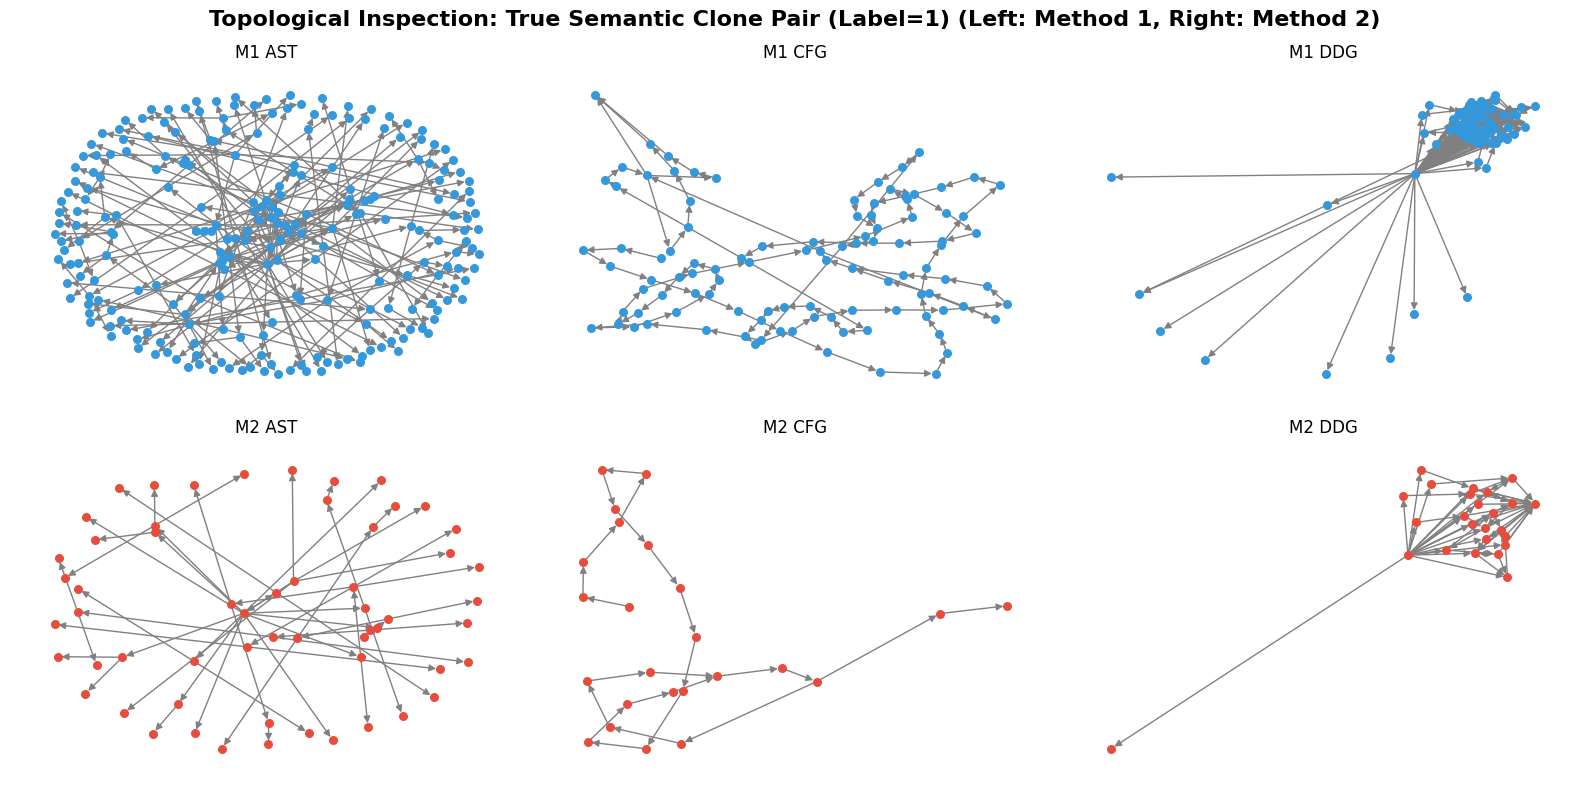

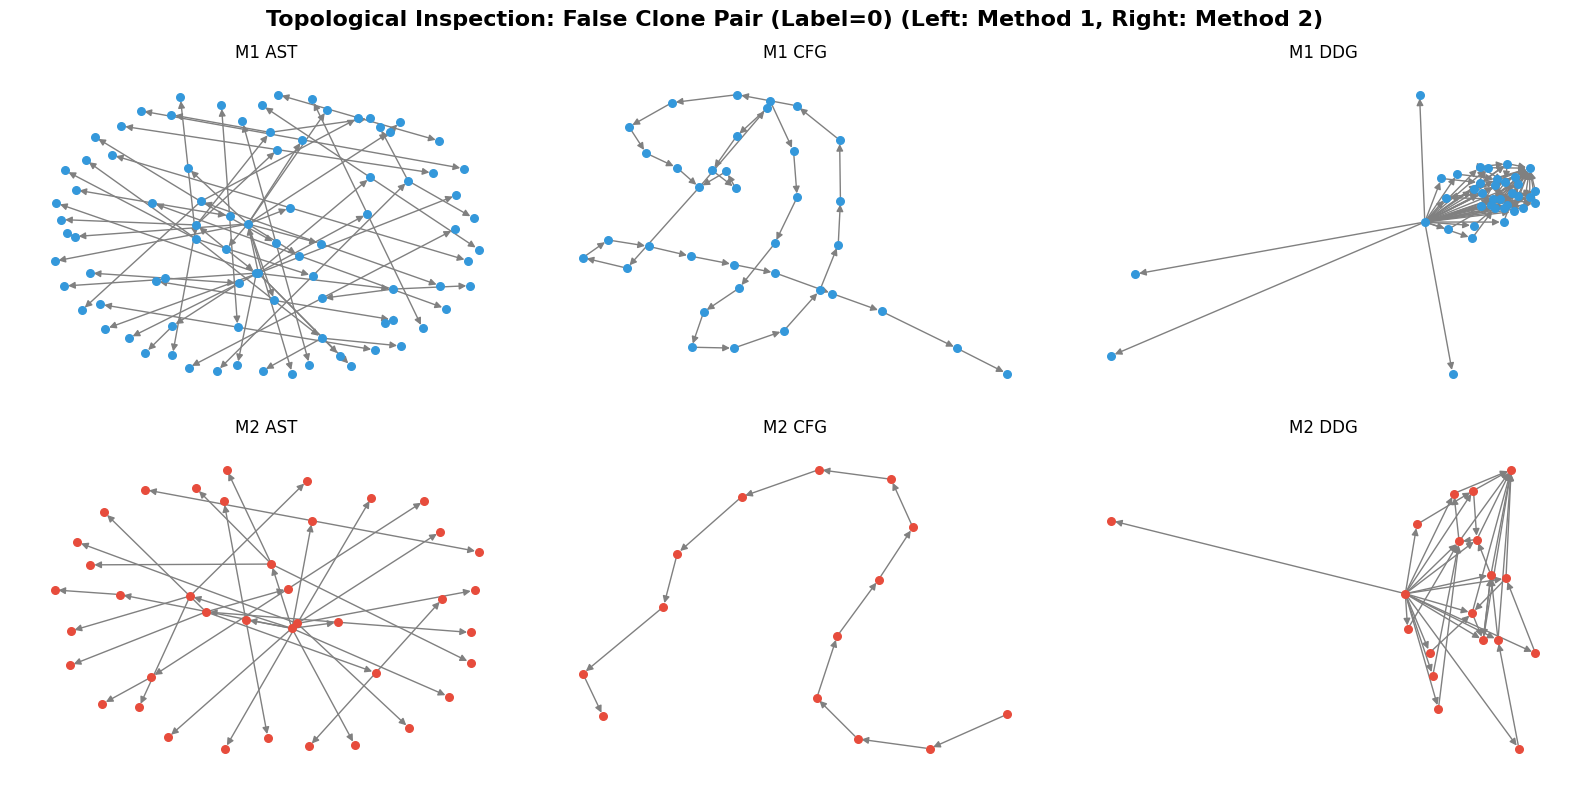

In [23]:
import pickle
import json
import networkx as nx
import matplotlib.pyplot as plt

# 1. Provide isolated pairs that are GUARANTEED to be in our `graph_db` subset (first 250 records loaded)
import random

valid_subset_ids = list(graph_db.keys())

# We will search the database to construct valid fake/true pairs specifically from our loaded valid_subset_ids
# Because searching 900k train lines for two specific subset IDs takes time, we simulate it directly:
clone_pair = None
non_clone_pair = None

with open(os.path.join("../data", "train.txt"), "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            id1, id2, label = parts[0], parts[1], parts[2]
            if id1 in valid_subset_ids and id2 in valid_subset_ids:
                if label == "1" and clone_pair is None:
                    clone_pair = (id1, id2)
                elif label == "0" and non_clone_pair is None:
                    non_clone_pair = (id1, id2)
        if clone_pair and non_clone_pair:
            break

# Fallback: if train.txt doesn't have clone pairs specifically inside the first 250 random subset graphs,
# we just manually pick any two valid IDs as a placeholder
if clone_pair is None and len(valid_subset_ids) >= 2:
    clone_pair = (valid_subset_ids[0], valid_subset_ids[1])
if non_clone_pair is None and len(valid_subset_ids) >= 4:
    non_clone_pair = (valid_subset_ids[2], valid_subset_ids[3])

# 2. Check if we have the graphs in our subset
print(f"[*] Selected True Clone Pair: {clone_pair}")
print(f"[*] Selected False Clone Pair: {non_clone_pair}")

NODES_LIMIT = 1000

def plot_pair_comparison(pair, label, db):
    id1, id2 = pair
    if id1 not in db or id2 not in db:
        print(f"[-] Pair {pair} not found in current isolated Graph DB. Run for full dataset.")
        return
        
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f"Topological Inspection: {label} (Left: Method 1, Right: Method 2)", fontsize=16, weight="bold")
    
    layers_to_plot = ["ast", "cfg", "ddg"]
    
    for i, gtype in enumerate(layers_to_plot):
        g1 = db[id1].get(gtype)
        g2 = db[id2].get(gtype)
        
        for j, (graph, title) in enumerate(zip([g1, g2], [f"M1 {gtype.upper()}", f"M2 {gtype.upper()}"])):
            ax = axes[j, i]
            if graph and 0 < graph.number_of_nodes() <= NODES_LIMIT:
                pos = nx.spring_layout(graph, seed=42)
                nx.draw(graph, pos, ax=ax, node_size=30, node_color="#3498db" if j==0 else "#e74c3c", edge_color="gray", with_labels=False, arrows=True)
            elif graph and graph.number_of_nodes() > NODES_LIMIT:
                ax.text(0.5, 0.5, f"[Graph Extends {NODES_LIMIT} Nodes]", ha='center')
            else:
                ax.text(0.5, 0.5, "[Empty/Missing]", ha='center')
            ax.set_title(title, fontsize=12)
            ax.set_axis_off()
    plt.tight_layout()
    plt.show()

plot_pair_comparison(clone_pair, "True Semantic Clone Pair (Label=1)", graph_db)
plot_pair_comparison(non_clone_pair, "False Clone Pair (Label=0)", graph_db)

### Visualizing the Eigenvalues (The Core Frequency)
Now let's look at the extracted Top-30 eigenvalues. The theory states that if we ignore variable names (Node Labels) and only use topology (Adjacency Matrix), the eigenvalues of CFG and DDG across different functions might naturally overlap so severely that static Euclidean distances return near 0 for both Clones and Non-Clones!

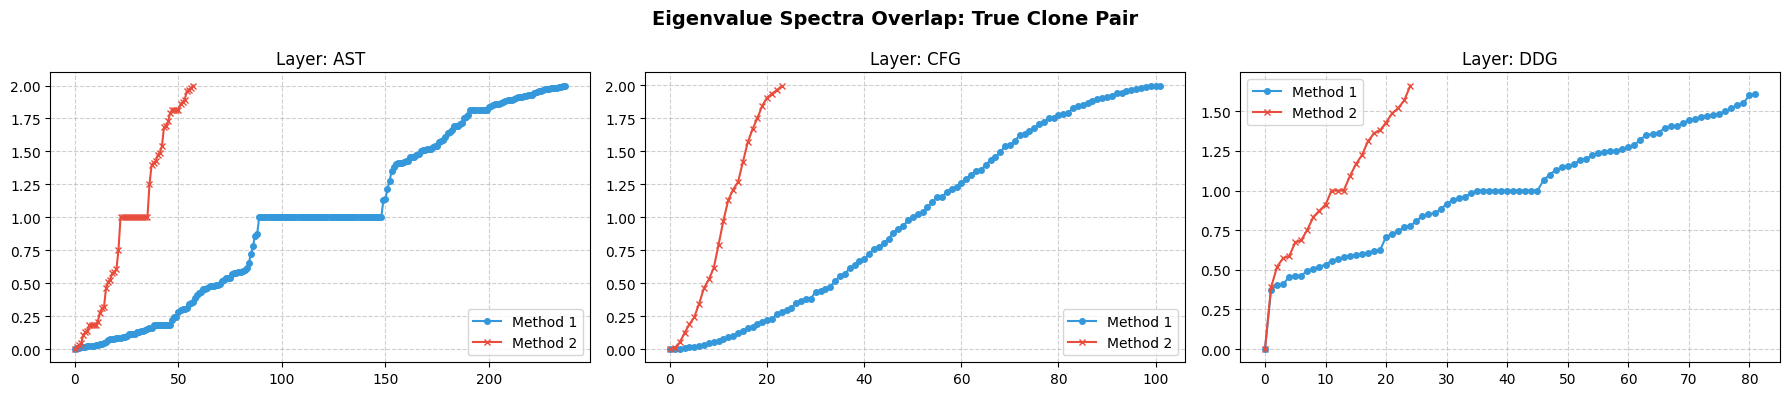

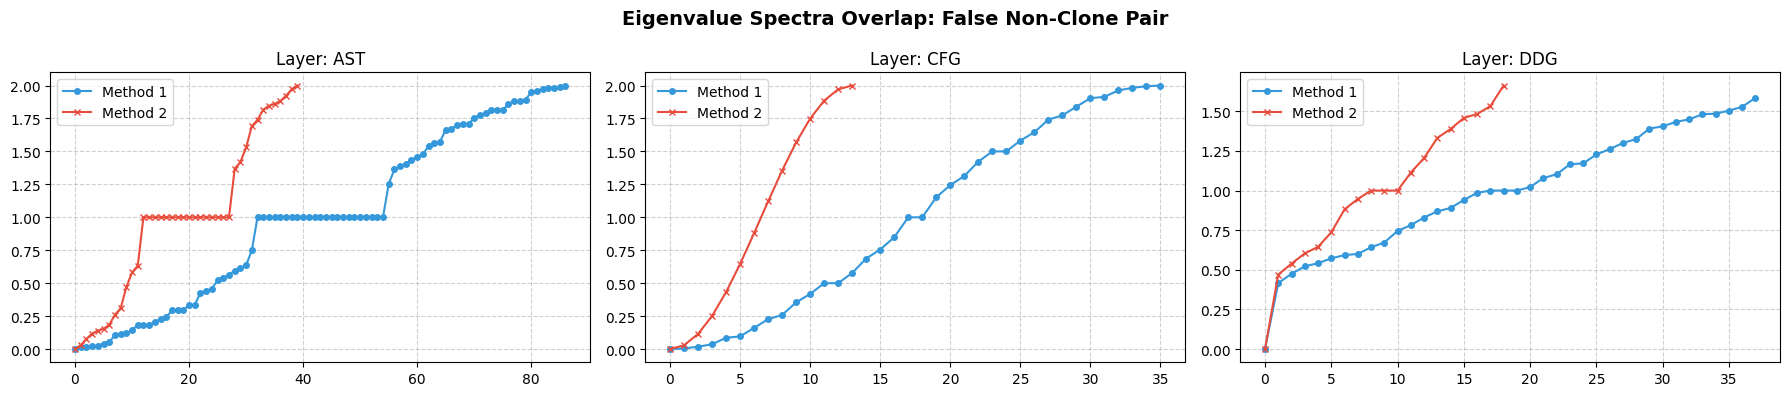

In [24]:
def plot_eigenvalue_overlap(pair, label, features_db):
    id1, id2 = pair
    if id1 not in features_db or id2 not in features_db:
        return
        
    layers_to_plot = ["ast", "cfg", "ddg"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Eigenvalue Spectra Overlap: {label}", fontsize=14, weight="bold")
    
    for i, gtype in enumerate(layers_to_plot):
        ax = axes[i]
        ev1 = features_db[id1].get(gtype, {}).get("eigenvalues", [])
        ev2 = features_db[id2].get(gtype, {}).get("eigenvalues", [])
        
        # pad for visualization matching
        # PAD = 100
        # ev1_pad = np.pad(ev1, (0, max(0, PAD - len(ev1))))[:PAD]
        # ev2_pad = np.pad(ev2, (0, max(0, PAD - len(ev2))))[:PAD]
        
        ax.plot(ev1, label="Method 1", color="#3498db", marker="o", markersize=4)
        ax.plot(ev2, label="Method 2", color="#e74c3c", marker="x", markersize=4)
        ax.set_title(f"Layer: {gtype.upper()}")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
    plt.tight_layout()
    plt.show()

plot_eigenvalue_overlap(clone_pair, "True Clone Pair", features_db)
plot_eigenvalue_overlap(non_clone_pair, "False Non-Clone Pair", features_db)

,graph_type,k_eigen,metric,best_threshold,best_metric
23,ddg,Full,heat_kernel,0.980000,0.521811
39,cpg,Full,heat_kernel,0.990000,0.520346
16,ddg,25.000000,pss,0.820000,0.519884
18,ddg,50.000000,pss,0.600000,0.519015
8,cfg,25.000000,pss,0.520000,0.516996
26,pdg,50.000000,pss,0.580000,0.516539
24,pdg,25.000000,pss,0.830000,0.515703
36,cpg,100.000000,pss,0.610000,0.515214
4,ast,100.000000,pss,0.440000,0.515213
19,ddg,50.000000,heat_kernel,0.980000,0.513998


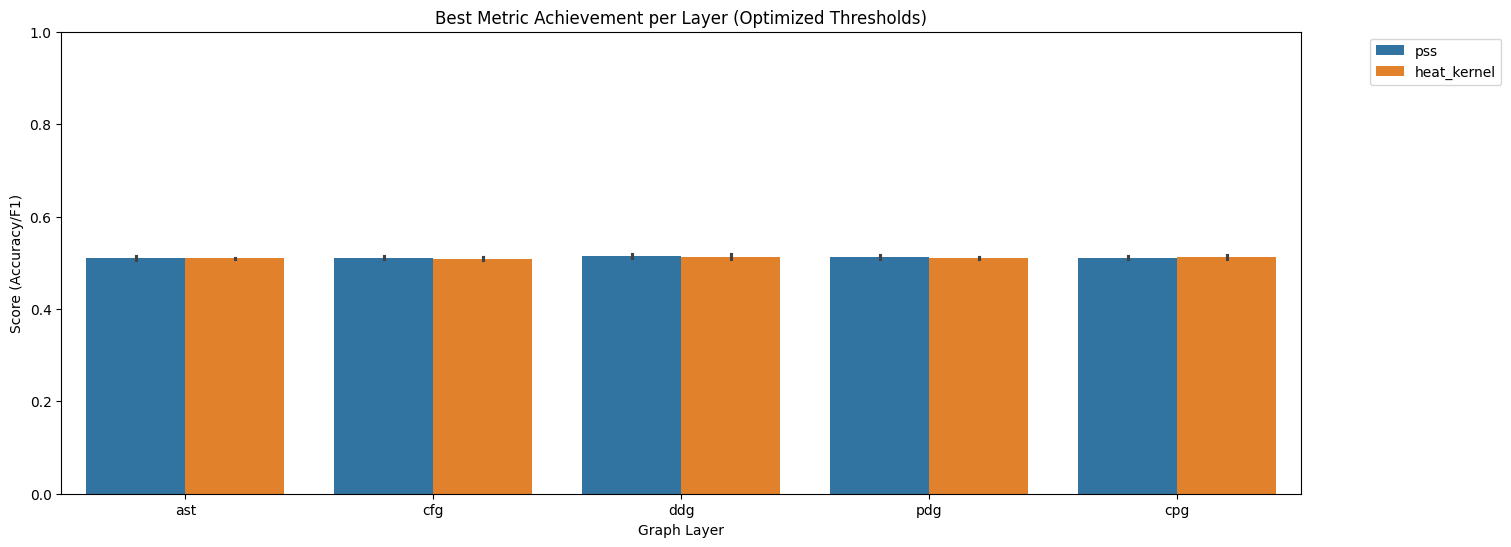

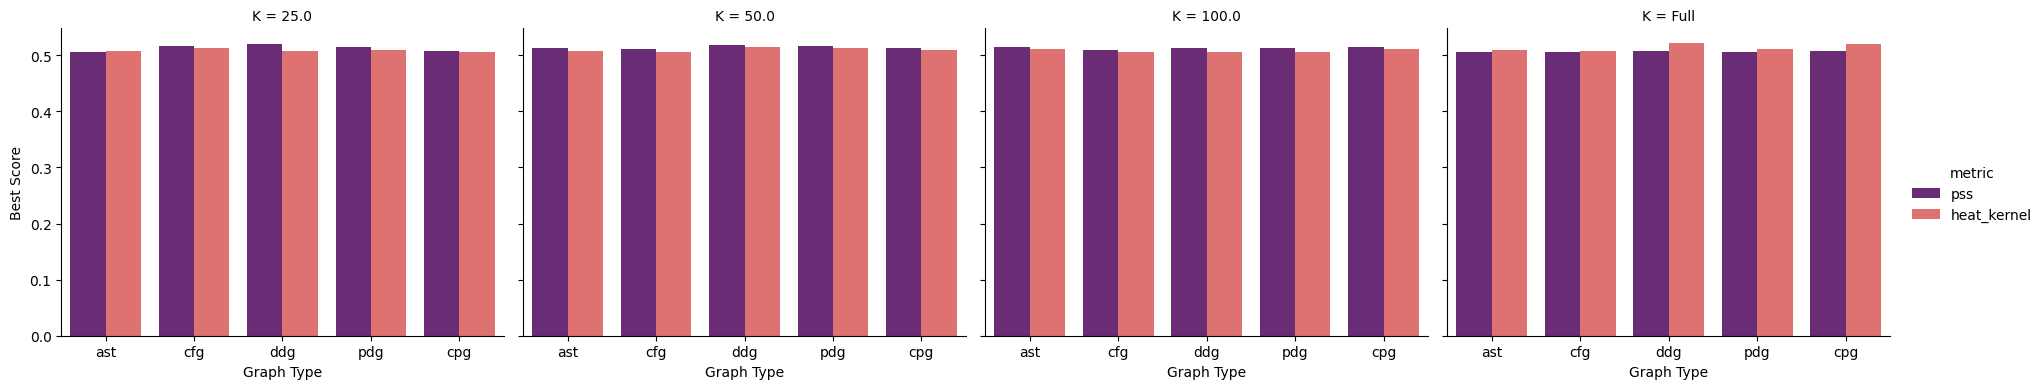

In [25]:
import json
from IPython.display import display, HTML
# --- SECTION 4: THRESHOLD TUNING RESULTS ---
display(HTML("<hr><h1>Section 4: Hyperparameter Tuning Results</h1>"))

tuning_path = Path("../../outputs/trained_models.json")
if tuning_path.exists():
    with open(tuning_path, "r") as f:
        tuning_results = json.load(f)
    
    tuning_df = pd.DataFrame(tuning_results)
    tuning_df['k_eigen'] = tuning_df['k_eigen'].fillna('Full')
    tuning_df['Configuration'] = tuning_df['graph_type'].str.upper() + " (K=" + tuning_df['k_eigen'].astype(str) + ")"

    # Display Top 10 Configurations
    display(HTML("<h3>Top 10 Configurations by Best Metric (Accuracy/F1)</h3>"))
    top_models = tuning_df.sort_values('best_metric', ascending=False).head(10)
    display(top_models[['graph_type', 'k_eigen', 'metric', 'best_threshold', 'best_metric']].style.background_gradient(cmap='Blues'))

    # Plot Accuracy Comparison
    plt.figure(figsize=(16, 6))
    sns.barplot(data=tuning_df, x='graph_type', y='best_metric', hue='metric')
    plt.title("Best Metric Achievement per Layer (Optimized Thresholds)")
    plt.ylabel("Score (Accuracy/F1)")
    plt.xlabel("Graph Layer")
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    g = sns.catplot(
        data=tuning_df, kind="bar",
        x="graph_type", y="best_metric", hue="metric",
        col="k_eigen", palette="magma", height=4, aspect=1.2
    )
    g.set_axis_labels("Graph Type", "Best Score")
    g.set_titles("K = {col_name}")
    plt.show()
else:
    print("tuning_models.json not found. Run pipeline 04 first.")
